# Phase 3B — Fine-tune BARTpho-word on ViMedAQA

**Model:** `vinai/bartpho-word` (~396M params)  
**Task:** Abstractive Question Answering  
**Input:** `question: {q} context: {c}` → `{answer}`  

**Platform support:**
- ✅ **Kaggle** (P100 GPU, 12h session, 30h/week quota)
- ✅ **Google Colab** (T4 GPU, requires Drive mount)

> ⚠️ **GPU REQUIRED.**
> Estimated training time: **4-8 hours** (5 epochs on T4).
> Note: T4 có thể gặp lỗi OOM (Out Of Memory) với BARTpho, do đó cấu hình Gradient Checkpointing, batch_size=2 và grad_accum=8 là bắt buộc.

## Cell 1 — Detect Platform & Verify GPU

In [2]:
import os, sys, torch

# ── Detect platform ──
ON_KAGGLE = os.path.exists("/kaggle")
ON_COLAB  = "google.colab" in sys.modules or os.path.exists("/content")

if ON_COLAB:
    PLATFORM = "Colab"
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = "/content/drive/MyDrive/vimedaq-project/data/processed"
    OUTPUT_ROOT = "/content/drive/MyDrive/vimedaq-project"
elif ON_KAGGLE:
    PLATFORM = "Kaggle"
    base_input = "/kaggle/input"
    subdirs = [os.path.join(base_input, d) for d in os.listdir(base_input) if os.path.isdir(os.path.join(base_input, d))]
    DATA_ROOT = next((d for d in subdirs if os.path.isfile(os.path.join(d, "train.json"))), base_input)
    OUTPUT_ROOT = "/kaggle/working"
else:
    PLATFORM = "Local"
    DATA_ROOT = os.path.join("..", "data", "processed")
    OUTPUT_ROOT = os.path.join("..")  # project root

print(f"Platform : {PLATFORM}")
print(f"Data root: {DATA_ROOT}")
print(f"Output   : {OUTPUT_ROOT}")

# ── Verify GPU ──
if not torch.cuda.is_available():
    raise RuntimeError(
        "⚠️ NO GPU DETECTED!\n"
        "  Kaggle : Settings → Accelerator → GPU P100\n"
        "  Colab  : Runtime → Change runtime type → T4 GPU"
    )

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\n✅ GPU: {gpu_name} ({vram_gb:.1f} GB VRAM)")

# ── Create output dirs ──
CHECKPOINT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints", "bartpho")
BEST_MODEL_DIR = os.path.join(CHECKPOINT_DIR, "best")
LOGS_DIR       = os.path.join(OUTPUT_ROOT, "logs")
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
print(f"Checkpoints: {BEST_MODEL_DIR}")
print(f"Logs       : {LOGS_DIR}")

Mounted at /content/drive
Platform : Colab
Data root: /content/drive/MyDrive/vimedaq-project/data/processed
Output   : /content/drive/MyDrive/vimedaq-project

✅ GPU: Tesla T4 (15.6 GB VRAM)
Checkpoints: /content/drive/MyDrive/vimedaq-project/checkpoints/bartpho/best
Logs       : /content/drive/MyDrive/vimedaq-project/logs


## Cell 2 — Install Dependencies
Thêm `pyvi` vào thư viện cài đặt do BARTpho-word bắt buộc phân tách từ (word segmentation).

In [3]:
# ===== CELL 2 — Install Dependencies =====
!pip install transformers==4.46.3 sentencepiece==0.2.0 datasets evaluate rouge-score accelerate pyvi -q

import transformers
print(f"✅ transformers {transformers.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.3 MB/s eta 0:00:00
✅ transformers 4.46.3


## Cell 3 — Load Data

In [4]:
import json
import os
from datasets import Dataset

train_path = None
if os.path.exists("/kaggle/input"):
    for root, dirs, files in os.walk("/kaggle/input"):
        for file in files:
            if file == "train.json":
                train_path = os.path.join(root, file)
                break
        if train_path: break

if not train_path:
    fallback_paths = [
        "/content/drive/MyDrive/vimedaq-project/data/processed/train.json",
        "../data/processed/train.json"
    ]
    for path in fallback_paths:
        if os.path.isfile(path):
            train_path = path
            break

if not train_path:
    raise FileNotFoundError("Không thấy file train.json!")

val_path = train_path.replace("train.json", "val.json")

def load_split(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_data = load_split(train_path)
val_data   = load_split(val_path)

train_dataset = Dataset.from_list(train_data)
val_dataset   = Dataset.from_list(val_data)

print(f"✅ Dataset loaded từ: {train_path}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

✅ Dataset loaded từ: /content/drive/MyDrive/vimedaq-project/data/processed/train.json
Train: 18843 | Val: 2355


## Cell 4 — Tokenizer & Preprocessing (with PyVi)

In [5]:
# ===== CELL 4 — Tokenizer & Preprocessing =====
from transformers import AutoTokenizer
from pyvi import ViTokenizer

MODEL_NAME = "vinai/bartpho-word"
MAX_INPUT_LEN = 1024  # BARTpho supports larger context
MAX_TARGET_LEN = 256

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(examples):
    inputs = []
    # Áp dụng word segmentation bắt buộc cho BARTpho-word
    for q, c in zip(examples["question"], examples["context"]):
        q_seg = ViTokenizer.tokenize(q)
        c_seg = ViTokenizer.tokenize(c)
        inputs.append(f"question: {q_seg} context: {c_seg}")

    targets = [ViTokenizer.tokenize(t) for t in examples["answer"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        padding="max_length",
        truncation=True,
    )
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        padding="max_length",
        truncation=True,
    )
    labels["input_ids"] = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing train set...")
train_tokenized = train_dataset.map(
    preprocess, batched=True, remove_columns=train_dataset.column_names,
)
print("Tokenizing val set...")
val_tokenized = val_dataset.map(
    preprocess, batched=True, remove_columns=val_dataset.column_names,
)
print(f"✅ Done! Train: {train_tokenized.shape} | Val: {val_tokenized.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train set...


Map:   0%|          | 0/18843 [00:00<?, ? examples/s]

Tokenizing val set...


Map:   0%|          | 0/2355 [00:00<?, ? examples/s]

✅ Done! Train: (18843, 4) | Val: (2355, 4)


## Cell 5 — Load Model & Gradient Checkpointing

In [6]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.to("cuda")

# KÍCH HOẠT GRADIENT CHECKPOINTING ĐỂ TRÁNH OOM TRÊN T4
model.gradient_checkpointing_enable()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params / 1e6:.1f}M")
print(f"Trainable params: {trainable_params / 1e6:.1f}M")
print(f"VRAM usage      : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Total params    : 420.4M
Trainable params: 420.4M
VRAM usage      : 1.68 GB


## Cell 6 — Training Configuration (OOM-Safe)

In [7]:
# ===== CELL 6 — Training Configuration =====
from transformers import (
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)
import evaluate
import numpy as np

# Do BARTpho-word lớn hơn và dùng MAX_INPUT=1024, phải giảm batch size và tăng grad_accum
BATCH_SIZE    = 2
GRAD_ACCUM    = 8
LEARNING_RATE = 3e-4
NUM_EPOCHS    = 5
WARMUP_STEPS  = 100
LOCAL_CKPT_DIR = os.path.join(OUTPUT_ROOT, "bartpho_local_ckpts")

training_args = Seq2SeqTrainingArguments(
    output_dir=LOCAL_CKPT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    fp16=True,
    gradient_checkpointing=True,  # Yêu cầu quan trọng
    logging_dir=LOGS_DIR,
    logging_steps=50,
    report_to="none",
    dataloader_num_workers=2,
)
print("✅ Training args configured for BARTpho.")
print(f"   Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

✅ Training args configured for BARTpho.
   Effective batch size: 16


## Cell 7 — Compute Metrics

In [8]:
rouge_metric = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.where(
        (preds >= 0) & (preds < tokenizer.vocab_size),
        preds, tokenizer.pad_token_id
    )
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]
    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {k: round(v, 4) for k, v in result.items()}

print("✅ compute_metrics defined.")

✅ compute_metrics defined.


## Cell 8 — Train

Hệ thống sẽ tự động resume từ local checkpoint nếu trước đó bị ngắt kết nối.

In [ ]:
from transformers.trainer_utils import get_last_checkpoint
import torch
import numpy as np
import os

# --- ĐOẠN MÃ KHẮC PHỤC TRIỆT ĐỂ PYTORCH 2.6 ---
# Cấp quyền cho toàn bộ các đối tượng Numpy cấu thành nên Checkpoint
try:
    torch.serialization.add_safe_globals([
        np.core.multiarray._reconstruct,
        np._core.multiarray._reconstruct,
        np.ndarray
    ])
except Exception:
    pass

# Tắt cảnh báo weights_only ở cấp độ môi trường
os.environ["TORCH_LOAD_WEIGHTS_ONLY"] = "0"
# -----------------------------------------------

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

last_checkpoint = get_last_checkpoint(LOCAL_CKPT_DIR)

if last_checkpoint:
    print(f"🚀 Resume từ: {last_checkpoint}")
else:
    print("🚀 Train từ đầu")

trainer.train(resume_from_checkpoint=last_checkpoint)

print("\n" + "=" * 60)
print("✅ Training complete!")

## Cell 9 — Save Best Model & CSV Log

In [11]:
import os
import json
from transformers.trainer_utils import get_last_checkpoint

# 1. Xác định checkpoint cuối cùng
last_checkpoint = get_last_checkpoint(LOCAL_CKPT_DIR)

if last_checkpoint:
    print(f"Tìm thấy checkpoint: {last_checkpoint}")

    # 2. Khởi tạo lại Trainer
    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # 3. Load trọng số mô hình
    trainer._load_from_checkpoint(last_checkpoint)

    # 4. QUAN TRỌNG: Load log history từ trainer_state.json
    state_path = os.path.join(last_checkpoint, "trainer_state.json")
    if os.path.exists(state_path):
        with open(state_path, "r") as f:
            trainer.state = trainer.state.load_from_json(state_path)
        print(f"✅ Đã khôi phục log_history ({len(trainer.state.log_history)} entries).")
    else:
        print("⚠️ Không tìm thấy file trainer_state.json trong checkpoint!")

    print("Giờ bạn hãy chạy lại cell vẽ biểu đồ.")
else:
    print("⚠️ Không tìm thấy checkpoint nào!")

Tìm thấy checkpoint: /content/drive/MyDrive/vimedaq-project/bartpho_local_ckpts/checkpoint-5885


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


✅ Đã khôi phục log_history (122 entries).
Giờ bạn hãy chạy lại cell vẽ biểu đồ.


In [ ]:
import pandas as pd

# Save best model
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f"✅ Best model saved: {BEST_MODEL_DIR}")

# List saved files
for f in os.listdir(BEST_MODEL_DIR):
    size = os.path.getsize(os.path.join(BEST_MODEL_DIR, f))
    print(f"   {f} ({size/1e6:.1f} MB)")

# Save training log ra file csv
log_path = os.path.join(LOGS_DIR, "bartpho_training_log.csv")
pd.DataFrame(trainer.state.log_history).to_csv(log_path, index=False)
print(f"\n✅ Training log saved: {log_path}")

# Print final metrics
print("\n── Final Eval Metrics ──")
for entry in reversed(trainer.state.log_history):
    if "eval_rougeL" in entry:
        print(f"  eval_rouge1 : {entry.get('eval_rouge1', 'N/A')}")
        print(f"  eval_rouge2 : {entry.get('eval_rouge2', 'N/A')}")
        print(f"  eval_rougeL : {entry.get('eval_rougeL', 'N/A')}")
        break

### Plot Training Progress
Sử dụng dữ liệu từ `trainer.state.log_history` để trực quan hóa quá trình hội tụ của mô hình.

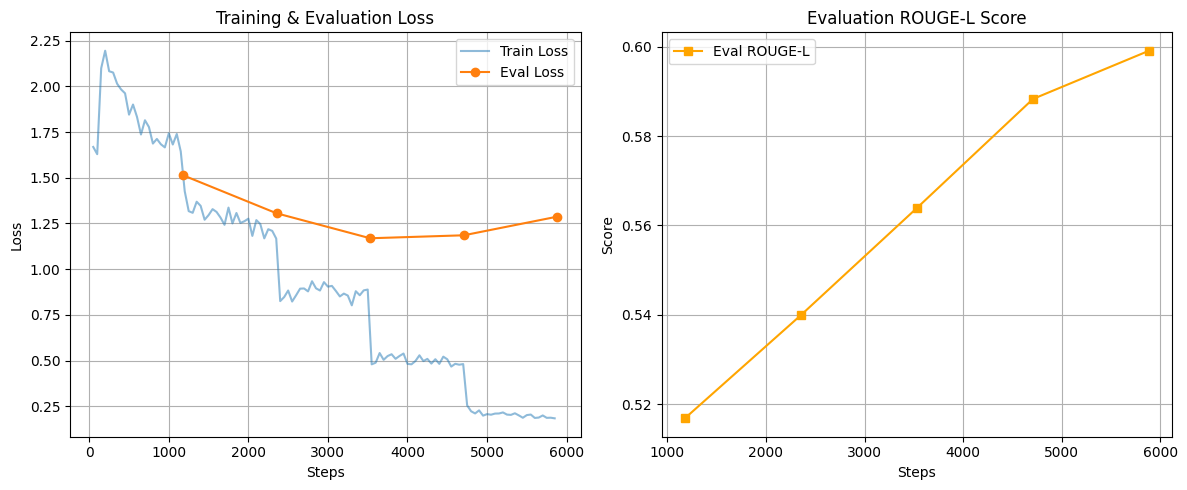

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Trích xuất log
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_rougeL = [x['eval_rougeL'] for x in history if 'eval_rougeL' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Train Loss', alpha=0.5)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Eval Loss', marker='o')
plt.title('Training & Evaluation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ ROUGE Score
plt.subplot(1, 2, 2)
if eval_rougeL:
    plt.plot(eval_steps, eval_rougeL, label='Eval ROUGE-L', color='orange', marker='s')
    plt.title('Evaluation ROUGE-L Score')
    plt.xlabel('Steps')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Identify Best Training Step
Đoạn mã này quét qua `log_history` để tìm step có `eval_rougeL` cao nhất.

In [15]:
best_entry = None
best_rougeL = -1

for entry in trainer.state.log_history:
    if "eval_rougeL" in entry:
        if entry["eval_rougeL"] > best_rougeL:
            best_rougeL = entry["eval_rougeL"]
            best_entry = entry

if best_entry:
    print(f"⭐ STEP TỐT NHẤT: {best_entry['step']}")
    print(f"📊 ROUGE-L: {best_entry['eval_rougeL']:.4f}")
    print(f"📉 Eval Loss: {best_entry.get('eval_loss', 'N/A')}")
    print(f"📅 Epoch: {best_entry['epoch']:.2f}")
    print(f"\nCheckpoint tương ứng sẽ nằm tại: {LOCAL_CKPT_DIR}/checkpoint-{best_entry['step']}")
else:
    print("⚠️ Không tìm thấy dữ liệu evaluation trong log history.")

⭐ STEP TỐT NHẤT: 5885
📊 ROUGE-L: 0.5991
📉 Eval Loss: 1.2876864671707153
📅 Epoch: 5.00

Checkpoint tương ứng sẽ nằm tại: /content/drive/MyDrive/vimedaq-project/bartpho_local_ckpts/checkpoint-5885


## Cell 10 — Sanity Check Inference

In [ ]:
from pyvi import ViTokenizer
model.eval()
samples = val_data[:5]

print("=" * 70)
print("SANITY CHECK — BARTpho Fine-tuned Inference")
print("=" * 70)

for idx, item in enumerate(samples):
    q_seg = ViTokenizer.tokenize(item['question'])
    c_seg = ViTokenizer.tokenize(item['context'])
    input_text = f"question: {q_seg} context: {c_seg}"

    inputs = tokenizer(
        input_text, return_tensors="pt",
        max_length=MAX_INPUT_LEN, truncation=True,
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True
        )

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
    pred = pred.replace("_", " ") # Gỡ bỏ dấu gạch dưới của pyvi để dễ đọc

    print(f"\n[{idx+1}] Q: {item['question'][:80]}")
    print(f"    Pred: {pred[:120]}")
    print(f"    Ref : {item['answer'][:120]}")
    print("-" * 70)

print("\n✅ Sanity check complete.")

### Compare Checkpoint 3531 vs 5885
Đoạn mã này tải lần lượt hai checkpoint và chạy thử nghiệm trên cùng 10 mẫu dữ liệu để so sánh trực quan.

In [17]:
import torch
from transformers import AutoModelForSeq2SeqLM

def get_prediction(model_path, samples):
    temp_model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to("cuda")
    temp_model.eval()
    preds = []
    for item in samples:
        q_seg = ViTokenizer.tokenize(item['question'])
        c_seg = ViTokenizer.tokenize(item['context'])
        input_text = f"question: {q_seg} context: {c_seg}"
        inputs = tokenizer(input_text, return_tensors="pt", max_length=MAX_INPUT_LEN, truncation=True).to("cuda")

        # Loại bỏ token_type_ids vì BARTpho không sử dụng nó trong generate
        if "token_type_ids" in inputs:
            del inputs["token_type_ids"]

        with torch.no_grad():
            outputs = temp_model.generate(**inputs, max_length=MAX_TARGET_LEN, num_beams=4)

        decoded = tokenizer.decode(outputs[0], skip_special_tokens=True).replace("_", " ")
        preds.append(decoded)

    del temp_model
    torch.cuda.empty_cache()
    return preds

# Chọn 10 câu đầu tiên từ val_data
test_samples = val_data[:10]
ckpt_3531_path = f"{LOCAL_CKPT_DIR}/checkpoint-3531"
ckpt_5885_path = f"{LOCAL_CKPT_DIR}/checkpoint-5885"

print("⏳ Đang chạy inference với Checkpoint 3531...")
preds_3531 = get_prediction(ckpt_3531_path, test_samples)

print("⏳ Đang chạy inference với Checkpoint 5885...")
preds_5885 = get_prediction(ckpt_5885_path, test_samples)

print("\n" + "="*100)
print(f"{'STT':<5} | {'Checkpoint 3531':<45} | {'Checkpoint 5885 (Best)':<45}")
print("-"*100)

for i in range(len(test_samples)):
    p3531 = preds_3531[i][:42] + "..." if len(preds_3531[i]) > 42 else preds_3531[i]
    p5885 = preds_5885[i][:42] + "..." if len(preds_5885[i]) > 42 else preds_5885[i]
    print(f"{i+1:<5} | {p3531:<45} | {p5885:<45}")
    print(f"Ground Truth: {test_samples[i]['answer']}")
    print("-"*100)

⏳ Đang chạy inference với Checkpoint 3531...
⏳ Đang chạy inference với Checkpoint 5885...

STT   | Checkpoint 3531                               | Checkpoint 5885 (Best)                       
----------------------------------------------------------------------------------------------------
1     | Các triệu chứng của hen suyễn về đêm bao g... | Các triệu chứng của hen suyễn về đêm thườn...
Ground Truth: Các triệu chứng của hen suyễn về đêm bao gồm tức ngực, khó thở, ho và thở khò khè vào ban đêm.
----------------------------------------------------------------------------------------------------
2     | Thùy chẩm là một trong bốn thùy chính tron... | Thùy chẩm là một trong bốn thùy chính tron...
Ground Truth: Hình dạng, màu sắc và vị trí của một vật thể vô cùng quan trọng đến chức năng của thùy chẩm, vì các thông tin này là yếu tố tạo nên thế giới thị giác xung quanh chúng ta.
----------------------------------------------------------------------------------------------------
3     

## Cell 11 — Download Model (Kaggle only)

In [ ]:
if ON_KAGGLE:
    import shutil
    archive_path = os.path.join(OUTPUT_ROOT, "bartpho_best_model")
    shutil.make_archive(archive_path, "zip", BEST_MODEL_DIR)
    print(f"✅ Model archived: {archive_path}.zip")
else:
    print(f"Model already saved at: {BEST_MODEL_DIR}")
    print("No additional download needed.")